In [6]:
# from sklearn import tree
# from sklearn.model_selection import cross_val_score
# from sklearn.model_selection import train_test_split
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import precision_score
# from sklearn.metrics import recall_score
# import ast
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# %matplotlib inline


In [7]:
train = pd.read_csv("train.csv")
test =  pd.read_csv("test.csv")
gender_submission =  pd.read_csv("gender_submission.csv")

In [8]:
X = train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived'], axis = 1)
X = pd.get_dummies(X)
X = X.fillna({'Age': X.Age.median()})
y = train.Survived

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42, stratify = y)

In [10]:
parameters = {'criterion' : ['gini', 'entropy'], 'max_depth' : range(1,30)}
clf = tree.DecisionTreeClassifier()
grid_search_cv_clf = GridSearchCV(clf, parameters, cv = 5)

In [11]:
grid_search_cv_clf.fit(X_train, y_train)
best_clf = grid_search_cv_clf.best_estimator_
y_predicted_prob = best_clf.predict_proba(X_test)

In [12]:
y_pred = np.where(y_predicted_prob[:, 1] > 0.8, 1, 0)

In [13]:
precision_score(y_test, y_pred)

0.95

In [14]:
recall_score(y_test, y_pred)

0.504424778761062

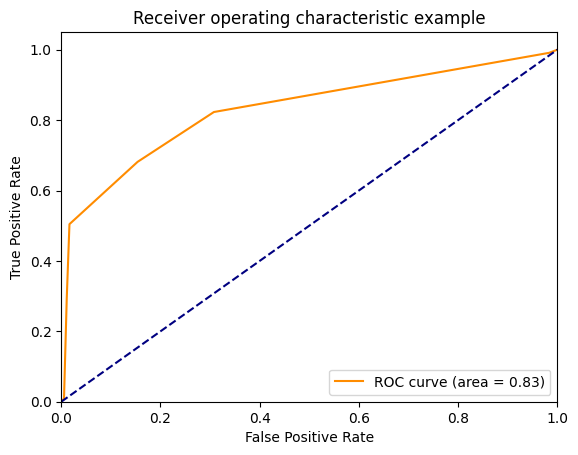

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Предположим, что y_test и y_predicted_prod уже определены
fpr, tpr, thresholds = roc_curve(y_test, y_predicted_prob[:, 1])
roc_auc = auc(fpr, tpr)

# Создание нового графического окна
plt.figure()

# Построение ROC-кривой
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")

# Отображение графика
plt.show()